In [1]:
import yfinance as yf
import pandas as pd
df = yf.Ticker("^NSEI").history(period="5y")
print(df.head())

                                   Open          High           Low  \
Date                                                                  
2021-10-08 00:00:00+05:30  17886.849609  17941.849609  17840.349609   
2021-10-11 00:00:00+05:30  17867.550781  18041.949219  17839.099609   
2021-10-12 00:00:00+05:30  17915.800781  18008.650391  17864.949219   
2021-10-13 00:00:00+05:30  18097.849609  18197.800781  18050.750000   
2021-10-14 00:00:00+05:30  18272.849609  18350.750000  18248.699219   

                                  Close  Volume  Dividends  Stock Splits  
Date                                                                      
2021-10-08 00:00:00+05:30  17895.199219  324100        0.0           0.0  
2021-10-11 00:00:00+05:30  17945.949219  375800        0.0           0.0  
2021-10-12 00:00:00+05:30  17991.949219  355600        0.0           0.0  
2021-10-13 00:00:00+05:30  18161.750000  506700        0.0           0.0  
2021-10-14 00:00:00+05:30  18338.550781  538700     

In [2]:
df.isnull().sum()

Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64

In [3]:
df.columns = df.columns.str.lower()
df = df[['close']]
df.head()

,close
Date,
2021-10-08 00:00:00+05:30,17895.199219
2021-10-11 00:00:00+05:30,17945.949219
2021-10-12 00:00:00+05:30,17991.949219
2021-10-13 00:00:00+05:30,18161.750000
2021-10-14 00:00:00+05:30,18338.550781


In [4]:
df['returns'] =  df['close'].pct_change()
df.head()

,close,returns
Date,,
2021-10-08 00:00:00+05:30,17895.199219,NaN
2021-10-11 00:00:00+05:30,17945.949219,0.002836
2021-10-12 00:00:00+05:30,17991.949219,0.002563
2021-10-13 00:00:00+05:30,18161.750000,0.009438
2021-10-14 00:00:00+05:30,18338.550781,0.009735


In [5]:
import numpy as np 
df['rolling_volatility'] = df['returns'].rolling(30).std()
df['annual_volatility'] = df['rolling_volatility']*np.sqrt(252)

In [6]:
import matplotlib.pyplot as plt


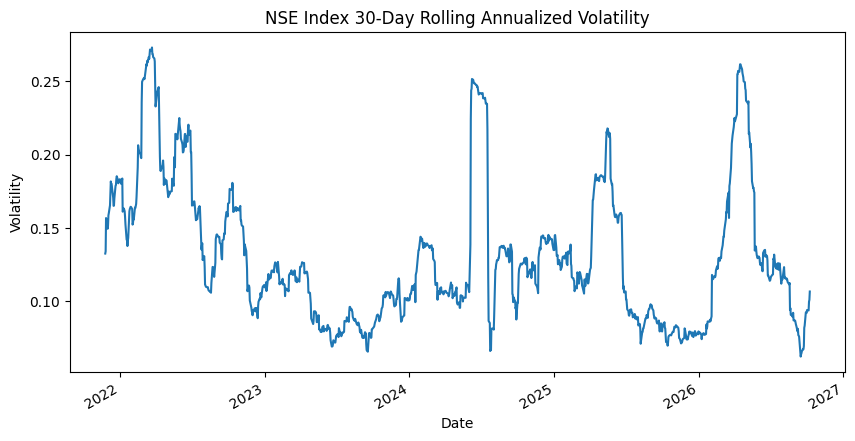

In [7]:
import matplotlib.pyplot as Plt 
plt.figure(figsize=(10,5))
df['annual_volatility'].plot()
plt.title("NSE Index 30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

In [8]:
df['cumulative_returns']=(1+df['returns']).cumprod()

In [9]:
df['running_max']=df['cumulative_returns'].cummax()

In [10]:
mean_returns = df['returns'].mean()
std_returns = df['returns'].std()

sharpe_ratio = (mean_returns / std_returns) * (252**0.5)

print("Sharpe Ratio", sharpe_ratio)

Sharpe Ratio 0.38941953561559667


In [11]:
std_returns = df['returns'].std()

In [12]:
print(df.head())
print(df.columns)

                                  close   returns  rolling_volatility  \
Date                                                                    
2021-10-08 00:00:00+05:30  17895.199219       NaN                 NaN   
2021-10-11 00:00:00+05:30  17945.949219  0.002836                 NaN   
2021-10-12 00:00:00+05:30  17991.949219  0.002563                 NaN   
2021-10-13 00:00:00+05:30  18161.750000  0.009438                 NaN   
2021-10-14 00:00:00+05:30  18338.550781  0.009735                 NaN   

                           annual_volatility  cumulative_returns  running_max  
Date                                                                           
2021-10-08 00:00:00+05:30                NaN                 NaN          NaN  
2021-10-11 00:00:00+05:30                NaN            1.002836     1.002836  
2021-10-12 00:00:00+05:30                NaN            1.005406     1.005406  
2021-10-13 00:00:00+05:30                NaN            1.014895     1.014895  
2021-10-

In [13]:
df['cumulative_return'] = (1 + df['returns']).cumprod()
df['running_max'] = df['cumulative_return'].cummax()
df['drawdown'] = (df['cumulative_return'] - df['running_max']) / df['running_max']

max_drawdown = df['drawdown'].min()
print("Maximum Drawdown:", max_drawdown)

Maximum Drawdown: -0.1722975608467003


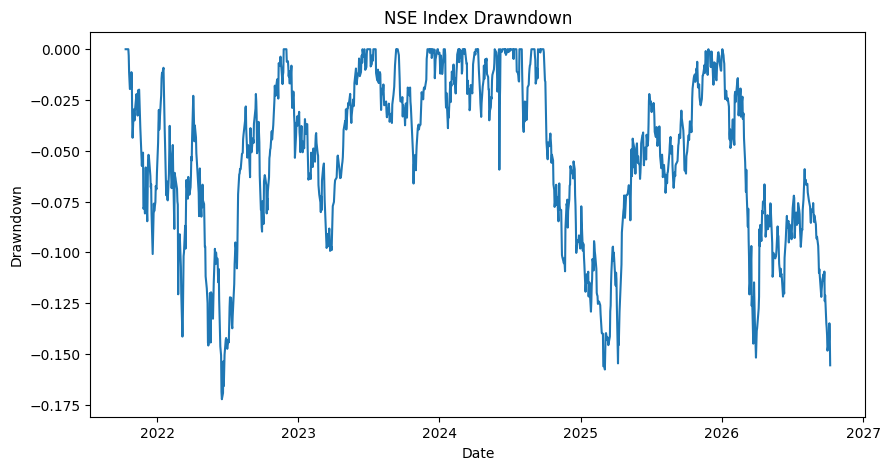

In [14]:
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,5))
plt.plot(df['drawdown'])
plt.title("NSE Index Drawndown")
plt.xlabel("Date")
plt.ylabel("Drawndown")
plt.show()

In [15]:
mean_return = df['returns'].mean()

In [16]:
std_return = df['returns'].std()

In [17]:
mean_returns=df['returns'].mean()
std_returns=df['returns'].std()
print(mean_returns)
print(std_returns)

0.00021393976924927586
0.008721156077884103


In [18]:
mean_returns=df['returns'].mean()
std_returns=df['returns'].std()
sharpe_ratio = (mean_return / std_return) * (252**0.5)
print("Sharpe Ratio:",sharpe_ratio)


Sharpe Ratio: 0.38941953561559667


In [19]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
tickers = ['RELIANCE.NS','ICICIBANK.NS','TCS.NS','INFY.NS','HDFCBANK.NS']
data = yf.download (tickers, start="2023-01-01", end="2026-01-01")
if isinstance(data.columns, pd.MultiIndex):
    df_close = data['Close']
else:
    df_close = data
    returns = df_close.pct_change().dropna()
    corr_matrix = returns.corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(returns.corr(), annotTrue, cmap='coolwarm', fmt='.2f', linewidths=0.5)
    plt.scatter(min_vol, min_ret,c="green",marker="*",s=200,label="Min Variance")
    plt.show()
                   

C:\Users\HP\AppData\Local\Temp\ipykernel_22764\2539141454.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download (tickers, start="2023-01-01", end="2026-01-01")
[*********************100%***********************]  5 of 5 completed


C:\Users\HP\AppData\Local\Temp\ipykernel_22764\510927968.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2023-01-01", end="2026-01-01")
[*********************100%***********************]  5 of 5 completed


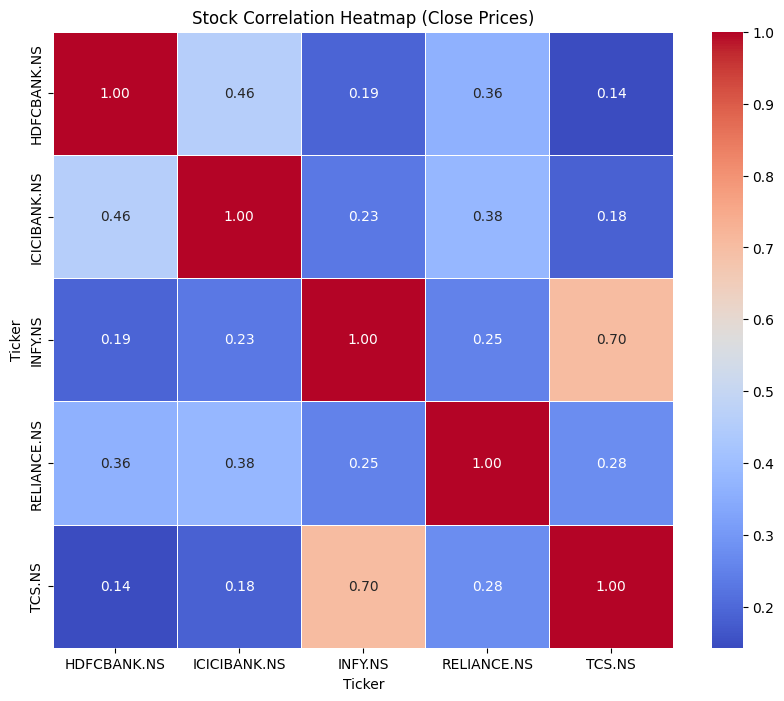

In [20]:
%matplotlib inline
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tickers = ['HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'TCS.NS']
data = yf.download(tickers, start="2023-01-01", end="2026-01-01")

if isinstance(data.columns, pd.MultiIndex):
    df_close = data['Close']
else:
    df_close = data

returns = df_close.pct_change().dropna()
corr_matrix = returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Stock Correlation Heatmap (Close Prices)')
plt.show()

In [21]:
import numpy as np
np.random.seed(42)
num_ports = 10000
all_weights = np.zeros((num_ports, len(tickers)))
ret_arr = np.zeros(num_ports)
vol_arr = np.zeros(num_ports)
sharpe_arr = np.zeros(num_ports)

mean_returns = returns.mean() * 252
cov_matrix = returns.cov() * 252

for i in range(num_ports):
    weights = np.random.random(len(tickers))
    weights = weights / np.sum(weights)
    all_weights[i,:] = weights
    ret_arr[i] = np.sum(mean_returns * weights)
    
    vol_arr[i] = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    
    
    sharpe_arr[i] = ret_arr[i] / vol_arr[i]
max_sharpe_idx = sharpe_arr.argmax()
print("Best Portfolio Weights:", all_weights[max_sharpe_idx])
print("Max Sharpe Ratio:", sharpe_arr[max_sharpe_idx])

Best Portfolio Weights: [0.08157881 0.66326932 0.06299532 0.15991547 0.03224107]
Max Sharpe Ratio: 0.9426879816445753


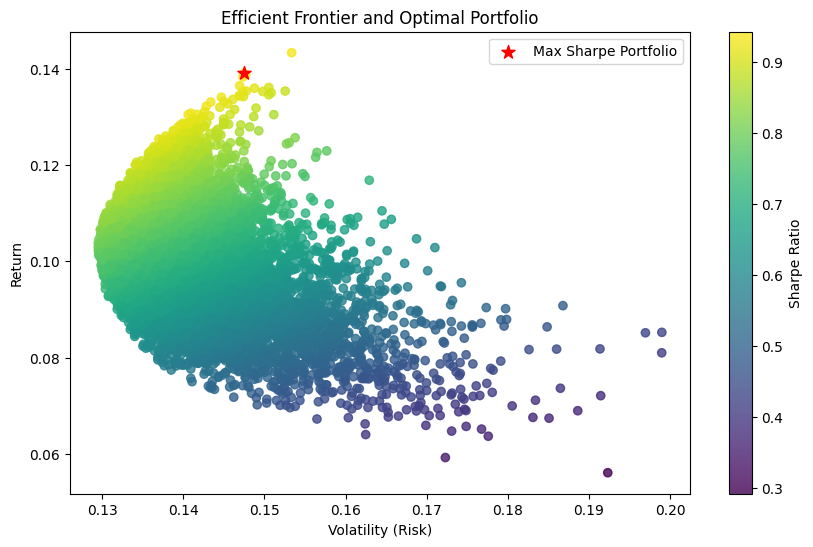

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr, cmap='viridis', marker='o', alpha=0.8)
plt.colorbar(label='Sharpe Ratio')
plt.xlabel('Volatility (Risk)')
plt.ylabel('Return')
plt.title('Efficient Frontier and Optimal Portfolio')

max_vol = vol_arr[max_sharpe_idx]
max_ret = ret_arr[max_sharpe_idx]
plt.scatter(max_vol, max_ret, c='red', s=100, marker='*', label='Max Sharpe Portfolio')
plt.legend(labelspacing=0.8)
plt.show()

In [23]:
from scipy.optimize import minimize

def get_portfolio_perf(weights):
    weights = np.array(weights)
    ret = np.sum(mean_returns * weights)
    vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe = ret / vol
    return -sharpe 

bounds = tuple((0.05, 0.30) for _ in range(len(tickers)))


constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})

init_guess = [1.0 / len(tickers)] * len(tickers)
optimized_result = minimize(get_portfolio_perf, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

print("Optimized Weights with Limits:", optimized_result.x)

Optimized Weights with Limits: [0.2619762 0.3       0.0880238 0.3       0.05     ]


In [24]:
from scipy.optimize import minimize

def neg_sharpe(weights):
    weights = np.array(weights)
    p_ret = np.sum(mean_returns * weights)
    p_vol = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return - (p_ret / p_vol)

bounds = tuple((0.05, 0.30) for _ in range(len(tickers)))

constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})


init_guess = [1.0 / len(tickers)] * len(tickers)

result = minimize(neg_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)

print("--- Optimized Weights with Caps ---")
for ticker, weight in zip(tickers, result.x):
    print(f"{ticker}: {weight * 100:.2f}%")

print(f"\nConstrained Max Sharpe Ratio: {-result.fun:.4f}")
print(dict(zip(df_close.columns,np.round(weights, 3))))

--- Optimized Weights with Caps ---
HDFCBANK.NS: 26.20%
ICICIBANK.NS: 30.00%
INFY.NS: 8.80%
RELIANCE.NS: 30.00%
TCS.NS: 5.00%

Constrained Max Sharpe Ratio: 0.8630
{'HDFCBANK.NS': np.float64(0.209), 'ICICIBANK.NS': np.float64(0.076), 'INFY.NS': np.float64(0.251), 'RELIANCE.NS': np.float64(0.175), 'TCS.NS': np.float64(0.289)}


{'HDFCBANK.NS': np.float64(30.0), 'ICICIBANK.NS': np.float64(5.0), 'INFY.NS': np.float64(8.0), 'RELIANCE.NS': np.float64(26.2), 'TCS.NS': np.float64(30.0)}
['HDFCBANK.NS', 'ICICIBANK.NS', 'INFY.NS', 'RELIANCE.NS', 'TCS.NS']


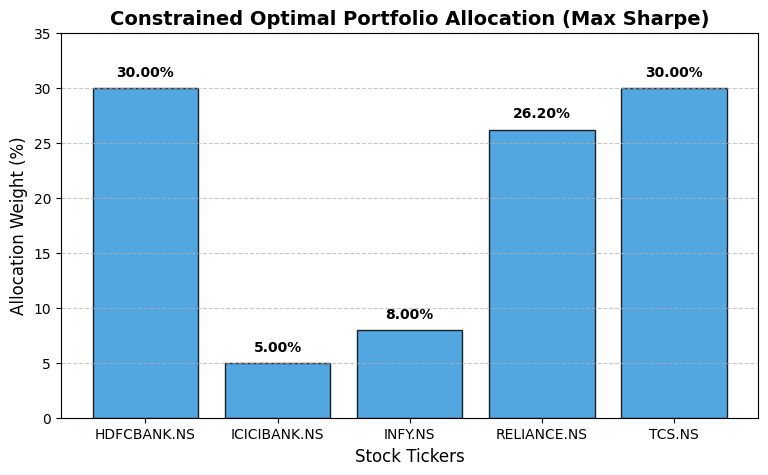

In [25]:
import matplotlib.pyplot as plt
weights_dict = {
    'HDFCBANK.NS': 0.3000,
    'ICICIBANK.NS': 0.0500,
    'INFY.NS': 0.0800,
    'RELIANCE.NS': 0.2620,
    'TCS.NS': 0.3000,
}

tickers = list(weights_dict.keys())
weights = [w * 100 for w in weights_dict.values()]  
plt.figure(figsize=(9, 5))
bars = plt.bar(tickers, weights, color='#3498db', edgecolor='black', alpha=0.85)

plt.xlabel('Stock Tickers', fontsize=12)
plt.ylabel('Allocation Weight (%)', fontsize=12)
plt.title('Constrained Optimal Portfolio Allocation (Max Sharpe)', fontsize=14, fontweight='bold')
plt.ylim(0, 35)  
print(dict(zip(df_close.columns,np.round(weights, 3))))
print(list(df_close.columns))
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.8, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()